In [1]:
import importlib.resources
import numpy as np
import matplotlib.pyplot as plt

try:
    import miepython

except ModuleNotFoundError:
    print('miepython not installed. To install, uncomment and run the cell above.')
    print('Once installation is successful, rerun this cell again.')

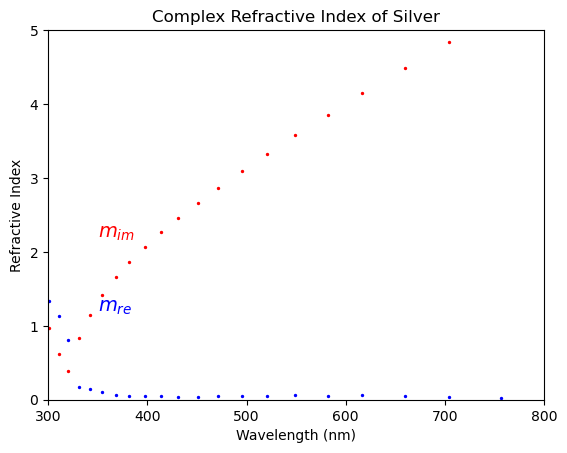

In [2]:
# import the Johnson and Christy data for silver
# ag = np.genfromtxt('https://refractiveindex.info/tmp/data/main/Ag/Johnson.txt', delimiter='\t')

nname = "data/ag-Johnson.txt"
ref = importlib.resources.files('miepython').joinpath(nname)
ag = np.genfromtxt(ref, delimiter='\t')

# data is stacked so need to rearrange
N = len(ag)//2
ag_lam = ag[1:N,0]
ag_mre = ag[1:N,1]
ag_mim = ag[N+1:,1]

plt.scatter(ag_lam*1000,ag_mre,s=2,color='blue')
plt.scatter(ag_lam*1000,ag_mim,s=2,color='red')
plt.xlim(300,800)
plt.ylim(0,5)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Refractive Index')
plt.text(350, 1.2, '$m_{re}$', color='blue', fontsize=14)
plt.text(350, 2.2, '$m_{im}$', color='red', fontsize=14)

plt.title('Complex Refractive Index of Silver')

plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\m'
C:\Users\zhaofei\AppData\Local\Temp\ipykernel_8328\4264716669.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.text(350, 0.35,'$\sigma_{abs}$', color='blue', fontsize=14)
C:\Users\zhaofei\AppData\Local\Temp\ipykernel_8328\4264716669.py:16: SyntaxWarning: invalid escape sequence '\s'
  plt.text(350, 0.54,'$\sigma_{sca}$', color='red', fontsize=14)
C:\Users\zhaofei\AppData\Local\Temp\ipykernel_8328\4264716669.py:17: SyntaxWarning: invalid escape sequence '\s'
  plt.text(350, 0.84,'$\sigma_{ext}$', color='green', fontsize=14)
C:\Users\zhaofei\AppData\Local\Temp\ipykernel_8328\4264

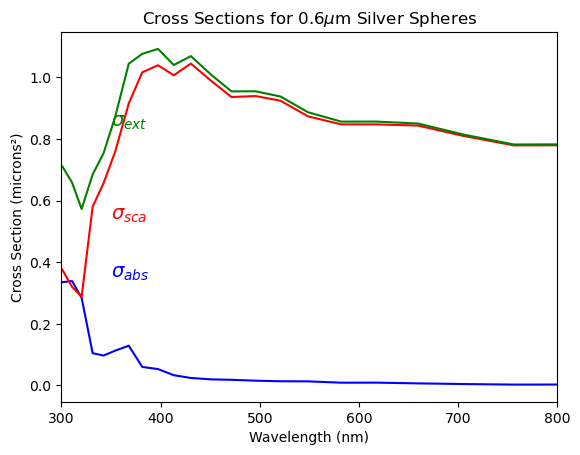

In [3]:
r = 0.3  #radius in microns
geometric_cross_section = np.pi * r**2

x = 2*np.pi*r/ag_lam;
m = ag_mre - 1.0j * ag_mim

qext, qsca, qback, g = miepython.mie(m,x)
absorb  = (qext - qsca) * geometric_cross_section
scatt   = qsca * geometric_cross_section
extinct = qext * geometric_cross_section

plt.plot(ag_lam*1000,absorb,color='blue')
plt.plot(ag_lam*1000,scatt,color='red')
plt.plot(ag_lam*1000,extinct,color='green')
plt.text(350, 0.35,'$\sigma_{abs}$', color='blue', fontsize=14)
plt.text(350, 0.54,'$\sigma_{sca}$', color='red', fontsize=14)
plt.text(350, 0.84,'$\sigma_{ext}$', color='green', fontsize=14)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Cross Section (microns²)")
plt.title("Cross Sections for %.1f$\mu$m Silver Spheres" % (r*2))

plt.xlim(300,800)
plt.show()

In [15]:
lambda0 = 375             # microns
a = 30/2         # also microns
k = 2*np.pi/lambda0     # per micron

m = 1.77-0.63j
x = a * k
geometric_cross_section = np.pi * a**2

theta = np.linspace(-180,180,180)
mu = np.cos(theta/180*np.pi)
s1,s2 = miepython.mie_S1_S2(m,x,mu)
phase = (abs(s1[0])**2+abs(s2[0])**2)/2

print('     unpolarized =',phase)
print('   |s1[-180]|**2 =',abs(s1[0]**2))
print('   |s2[-180]|**2 =',abs(s2[0]**2))
print('   |s1[ 180]|**2 =',abs(s1[179]**2))
print('   |s2[ 180]|**2 =',abs(s2[179]**2))
print()

qext, qsca, qback, g = miepython.mie(m,x)
ssa = qsca/qext
Cback = qback * geometric_cross_section
Csca  = qsca  * geometric_cross_section

print('            Csca =',Csca)
print('           Cback =',Cback)
print('4*pi*Csca*p(180)/ssa =',4*np.pi*Csca*phase/ssa)

     unpolarized = 0.001392327929197408
   |s1[-180]|**2 = 0.001392327929197408
   |s2[-180]|**2 = 0.001392327929197408
   |s1[ 180]|**2 = 0.001392327929197408
   |s2[ 180]|**2 = 0.001392327929197408

            Csca = 2.2304941115153336
           Cback = 3.242116442957233
4*pi*Csca*p(180)/ssa = 3.242116548807752


In [13]:
lambda0 = 1             # microns
a = lambda0/10          # also microns
k = 2*np.pi/lambda0     # per micron

m = 1.5-0.1j
x = a * k
geometric_cross_section = np.pi * a**2

theta = np.linspace(-180,180,180)
mu = np.cos(theta/180*np.pi)
s1,s2 = miepython.mie_S1_S2(m,x,mu)
phase = (abs(s1[0])**2+abs(s2[0])**2)/2

print('     unpolarized =',phase)
print('   |s1[-180]|**2 =',abs(s1[0]**2))
print('   |s2[-180]|**2 =',abs(s2[0]**2))
print('   |s1[ 180]|**2 =',abs(s1[179]**2))
print('   |s2[ 180]|**2 =',abs(s2[179]**2))
print()

qext, qsca, qback, g = miepython.mie(m,x)

Cback = qback * geometric_cross_section
Csca  = qsca  * geometric_cross_section
ssa = qsca/qext

print('            Csca =',Csca)
print('           Cback =',Cback)
print('4*pi*Csca*p(180) =',4*np.pi*Csca*phase/ssa)

     unpolarized = 0.019617198270557638
   |s1[-180]|**2 = 0.01961719827055764
   |s2[-180]|**2 = 0.01961719827055764
   |s1[ 180]|**2 = 0.01961719827055764
   |s2[ 180]|**2 = 0.01961719827055764

            Csca = 0.0011663349565709765
           Cback = 0.0014410454943489914
4*pi*Csca*p(180) = 0.0014410454945474138
